In [4]:
import numpy as np
import FitCumulants_corrected as fc
import matplotlib.pyplot as plt
import tifffile as tif
import os 
import scipy.optimize as opt
import glob
# import fokkerplanck as fp
import bayes_fit as bf
import json
# %matplotlib widget

# check cumulant results

In [5]:
path = r'C:\Users\teole\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\cumulants_allstaygold'
files = glob.glob(path + r'\\**.npz')
print(len(files))

e2rad = [3.02213117, 2.32541009]
# gamma_vals = [1, 0.0606938534730476, 0.00471750827466804] # 90nm pix STED
# gamma_vals = [1, 0.140299537175068, 0.0306342664169342] # 150nm pix STED

# gamma_valsy = [1, 0.0318001385121742, 0.00123720646999103] # 150nm pix STED
# gamma_valsr = [1, 0.0522424698204476, 0.00372642894648439] # 150nm pix STED

863


file 0 bad value in: C:\Users\teole\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\cumulants_allstaygold\20250124_at1r-g13_measurement1a_set10_cumulants.npz


<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:76: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:76: SyntaxWarning: invalid escape sequence '\m'
C:\Users\teole\AppData\Local\Temp\ipykernel_17600\100567566.py:70: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Photons/protein (2.5 $\mu$s dwell time)')
C:\Users\teole\AppData\Local\Temp\ipykernel_17600\100567566.py:76: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Photons/protein (2.5 $\mu$s dwell time)')


N too high
file 1 bad fit: C:\Users\teole\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\cumulants_allstaygold\20250124_at1r-g13_measurement1b_set10_cumulants.npz
N too high
file 2 bad fit: C:\Users\teole\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\cumulants_allstaygold\20250124_at1r-g13_measurement1_set10_cumulants.npz
NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.
file 3 bad fit: C:\Users\teole\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\cumulants_allstaygold\20250124_at1r-g13_measurement2a_set10_cumulants.npz
NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan

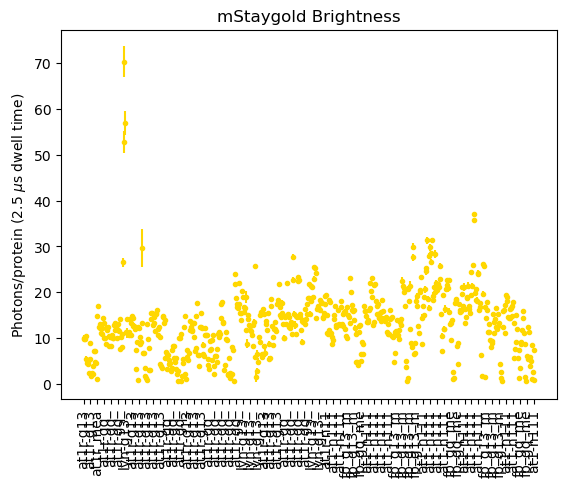

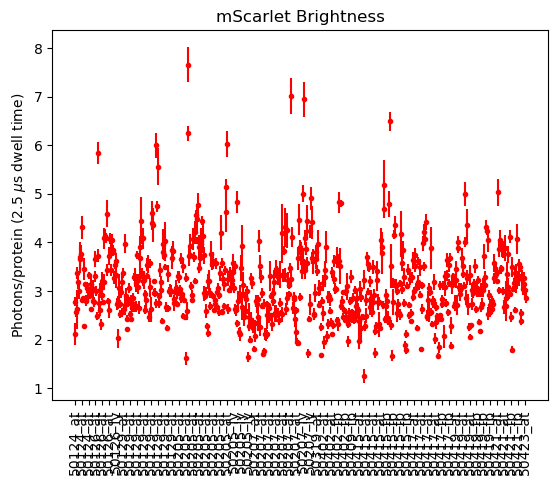

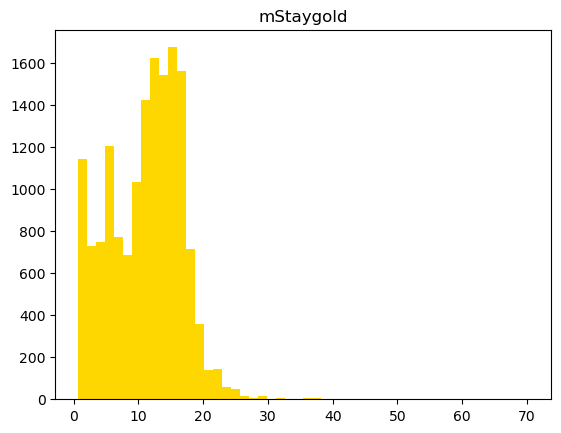

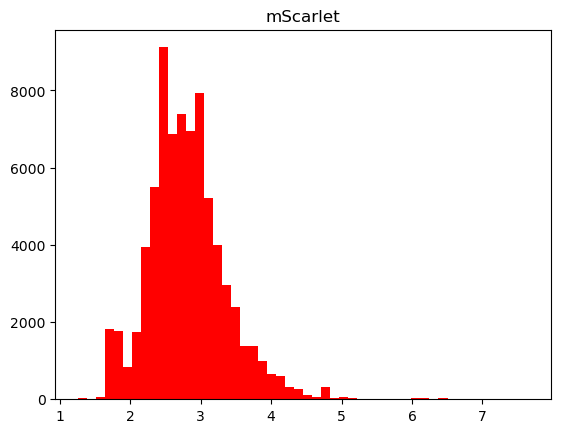

In [6]:
byvals = []
byerrs = []
nyvals = []
nyerrs = []
brvals = []
brerrs = []
nrvals = []
nrerrs = []
xpos = []
means = []
for i in range(len(files)):
    
    f = files[i]
    fdict = np.load(f)
    cumulants = fdict['cumulants']
    variances = fdict['variances']
    Npixels = fdict['Npixels']

    if np.any(np.logical_not(np.isfinite(variances))) or np.any(np.logical_not(np.isfinite(cumulants))):
        print(f'file {i} bad value in:', f)
        continue

    cumulants = cumulants[Npixels > np.quantile(Npixels, 0.9)*0.75]
    variances = variances[Npixels > np.quantile(Npixels, 0.9)*0.75]
    max_len = 25 #cumulants.shape[1]//3 # just use the first half to avoid drift and bleaching.
    ymask = np.array([1, 0, 1, 0, 0, 1, 0, 0, 0])
    rmask = np.array([0, 1, 0, 1, 0, 0, 1, 0, 0])

    cum1cy = cumulants[:, ymask==1]
    var1cy = variances[:, ymask==1]
    cum1cr = cumulants[:, rmask==1]
    var1cr = variances[:, rmask==1]
    try:
        fit1 = fc.fit_cumulants([1.0], [3.0], [0], e2rad[0], cum1cy[:max_len], var1cy[:max_len], two_color=False, varyN=True, varyB=True, varyback=False, varygamma=False, bmax=100)
        fit2 = fc.fit_cumulants([1.0], [2.0], [0], e2rad[1], cum1cr[:max_len], var1cr[:max_len], two_color=False, varyN=True, varyB=True, varyback=False, varygamma=False)
        if fit1.params['N1'].value > 50:
            raise Exception('N too high')
        if fit1.params['B1'].stderr is None:
            raise Exception('None error')
        byvals.append(fit1.params['B1'].value)
        byerrs.append(fit1.params['B1'].stderr)   
        nyvals.append(fit1.params['N1'].value)
        nyerrs.append(fit1.params['N1'].stderr)   
        means.append(cum1cy[0, 0])
        brvals.append(fit2.params['B1'].value)
        brerrs.append(fit2.params['B1'].stderr)  
        nrvals.append(fit2.params['N1'].value)
        nrerrs.append(fit2.params['N1'].stderr)  
        xpos.append(i)
    except Exception as e:
        print(e)
        print(f'file {i} bad fit:', f)


byvals = np.array(byvals)
byerrs = np.array(byerrs)
nyvals = np.array(nyvals)
nyerrs = np.array(nyerrs)
brvals = np.array(brvals)
brerrs = np.array(brerrs)
nrvals = np.array(nrvals)
nrerrs = np.array(nrerrs)
xpos = np.array(xpos)
means = np.array(means)

plt.figure()
plt.title('mStaygold Brightness')
plt.errorbar(np.arange(len(byvals)), byvals, yerr=byerrs, fmt='.', color='gold')
plt.xticks(np.arange(0, len(byvals), 10), [files[i][117:125] for i in np.arange(0, len(byvals), 10)], rotation='vertical')
plt.ylabel('Photons/protein (2.5 $\mu$s dwell time)')

plt.figure()
plt.title('mScarlet Brightness')
plt.errorbar(np.arange(len(brvals)), brvals, yerr=brerrs, fmt='.', color='r')
plt.xticks(np.arange(0, len(brvals), 10), [files[i][111:119] for i in np.arange(0, len(brvals), 10)], rotation='vertical')
plt.ylabel('Photons/protein (2.5 $\mu$s dwell time)')

plt.figure()
plt.title('mStaygold')
plt.hist(byvals, 50, weights=1/(byerrs**2), color='gold')
plt.figure()
plt.title('mScarlet')
plt.hist(brvals, 50, weights=1/(brerrs**2), color='r')
plt.show()

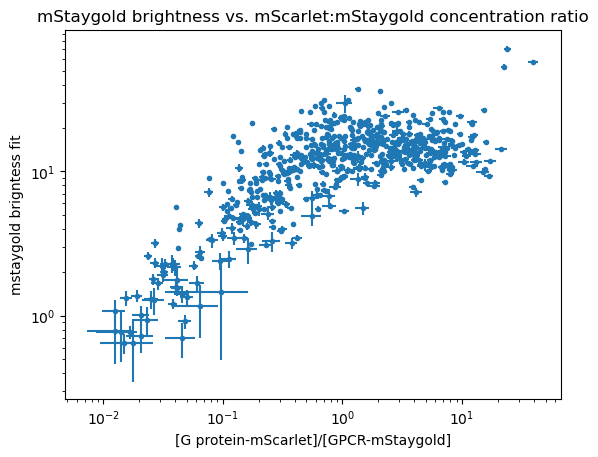

In [15]:
plt.figure()
plt.title('mStaygold brightness vs. mScarlet:mStaygold concentration ratio')
xerrs = nrvals/nyvals * np.sqrt((nrerrs/nrvals)**2 + (nyerrs/nyvals)**2)

plt.errorbar(nrvals/nyvals, byvals, yerr=byerrs, xerr=xerrs, fmt='.' )
plt.semilogx()
plt.semilogy()
plt.ylabel('mstaygold brigntess fit')
plt.xlabel('[G protein-mScarlet]/[GPCR-mStaygold]')
plt.show()

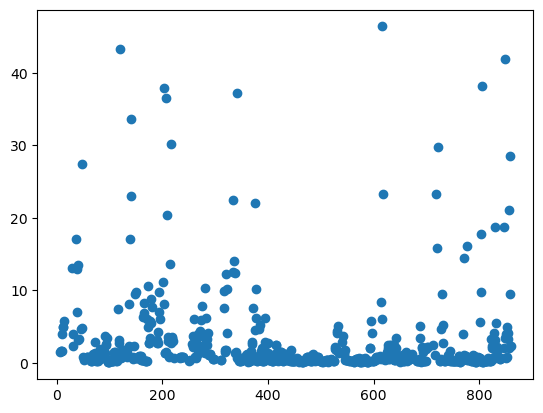

In [8]:
plt.figure()
plt.scatter(xpos, nyvals, )
plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
C:\Users\teole\AppData\Local\Temp\ipykernel_17600\4093732212.py:46: SyntaxWarning: invalid escape sequence '\p'
  plt.text(5., 0.2, f'Brightness {round(ypopt[0],3)} $\pm$ {round(ypopt[1], 5)}\n(photons/protein)')
C:\Users\teole\AppData\Local\Temp\ipykernel_17600\4093732212.py:63: SyntaxWarning: invalid escape sequence '\p'
  plt.text(14, 0.05, f'monomer brightness {round(y2popt[0],3)} $\pm$ {round(y2popt[2], 5)}\n\ndimer brightness {round(y2popt[1],3)} $\pm$ {round(y2popt[3], 5)}  \n(photons/protein)')
C:\Users\teole\AppData\Local\Temp\ipykernel_17600\4093732212.py:63: SyntaxWarning: invalid escape sequence '\p'
  plt.text(14, 0.05, f'monomer brightness {round(y2popt[0],3)} $\pm$ {roun

640
[10.5972262   8.13486513]
2 gaussians
4.433287891641097 (+/-) 2.2576191224189337
14.468880022952662 (+/-) 0.28631621826564496
6.8212940924035985 (+/-) 4.26867573516868
2.865807887225398 (+/-) 0.5565016354927149
24.52018495199798 (+/-) 2.157551723667588
14.045080797476121 (+/-) 3.995066769476009


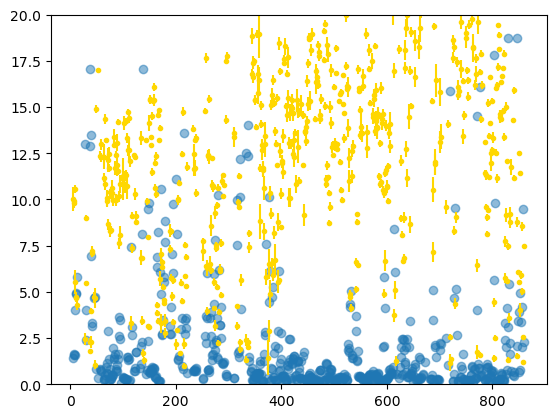

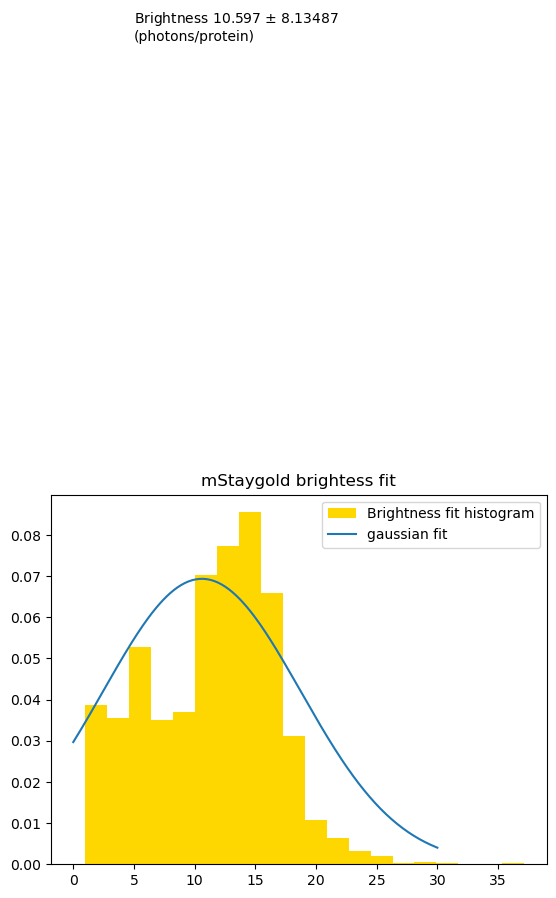

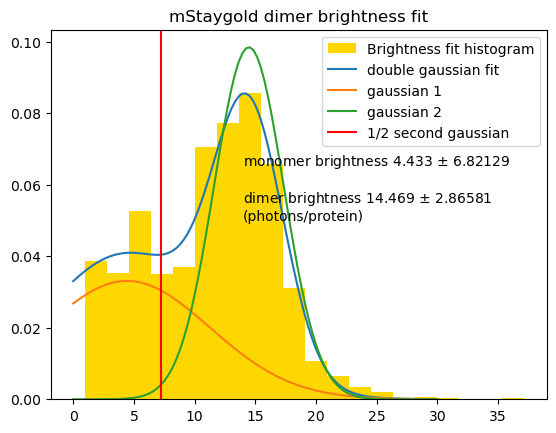

In [9]:
def gaussian(x, mu, sigma):
    return np.exp(-(x-mu)**2/(2*sigma**2))/(sigma*np.sqrt(np.pi))

def double_gaussian(x, mu1, mu2, sigma1, sigma2, a1, a2):
    return np.exp(-(x-mu1)**2/(2*sigma1**2))/a1 + np.exp(-(x-mu2)**2/(2*sigma2**2))/a2

# manually select that nice section in the mstaygold brightness fit. NEED TO GO OVER IMAGES TO CONFIRM WHAT IS GIVING GOOD AND BAD RESULTS HERE!
filtyerrs =   byerrs[np.logical_and(byvals>1, byvals<40)]
filtnyvals =  nyvals[np.logical_and(byvals>1, byvals<40)]
filtnyerr =   nyerrs[np.logical_and(byvals>1, byvals<40)]
filtxpos =      xpos[np.logical_and(byvals>1, byvals<40)]
filtmeans =    means[np.logical_and(byvals>1, byvals<40)]
filtyvals =   byvals[np.logical_and(byvals>1, byvals<40)]
# filtyerrs = byerrs[byvals>6]
# filtyvals = byvals[byvals>6]

plt.figure()
plt.errorbar(filtxpos, filtyvals, yerr=filtyerrs, fmt='.', color='gold')
plt.scatter(filtxpos, filtnyvals, alpha=0.5)
plt.ylim(0,20)


print(len(filtyvals))

yhist, binedges = np.histogram(filtyvals, weights=1/(filtyerrs**2), bins=80, density=True)
ybincenters = np.diff(binedges)[0]/2 + binedges[:-1]

ypopt, ypcov = opt.curve_fit(gaussian, ybincenters, yhist, p0=(5, 5))
yperr = np.sqrt(np.diag(ypcov))
print(ypopt)

# plt.figure()
# plt.title('mScarlet brightness fit')
# # plt.plot(bincenters, rhist, )
# plt.hist(brvals, weights=1/(brerrs**2), bins=50, density=True, color='r', label='Brightness fit histogram')
# plt.plot(np.linspace(0, np.max(brvals), 100), gaussian(np.linspace(0, np.max(brvals), 100), rpopt[0], rpopt[1]), label='gaussian fit')
# plt.text(4., 0.8, f'Brightness {round(rpopt[0],3)} $\pm$ {round(rpopt[1], 5)}\n(photons/protein)')
# plt.legend()


plt.figure()
plt.title('mStaygold brightess fit')
# plt.plot(bincenters, rhist, )
plt.hist(filtyvals, weights=1/(filtyerrs**2), bins=20, density=True, color='gold', label='Brightness fit histogram')
plt.plot(np.linspace(0, 30, 200), gaussian(np.linspace(0,30,200), ypopt[0], ypopt[1]), label='gaussian fit')
plt.text(5., 0.2, f'Brightness {round(ypopt[0],3)} $\pm$ {round(ypopt[1], 5)}\n(photons/protein)')
plt.legend()

y2popt, y2pcov = opt.curve_fit(double_gaussian, ybincenters, yhist, p0=(5, 10,3, 3, 1, 1) )
y2err = np.sqrt(np.diag(y2pcov))
print("2 gaussians")
for i in range(len(y2popt)):
    print(y2popt[i], "(+/-)", y2err[i])

plt.figure()
plt.title('mStaygold dimer brightness fit')
plt.hist(filtyvals, weights=1/(filtyerrs**2), bins=20, density=True, color='gold', label='Brightness fit histogram')
plt.plot(np.linspace(0, 30, 100), double_gaussian(np.linspace(0,30,100), y2popt[0], y2popt[1], y2popt[2], y2popt[3], y2popt[4], y2popt[5]), label='double gaussian fit')
plt.plot(np.linspace(0, 30, 100), gaussian(np.linspace(0, 30, 100), y2popt[0], y2popt[2])/2.5, label='gaussian 1')
plt.plot(np.linspace(0, 30, 100), gaussian(np.linspace(0, 30, 100), y2popt[1], y2popt[3])/2, label='gaussian 2')
plt.axvline(y2popt[1]/2, c='r', label='1/2 second gaussian')
plt.legend()
plt.text(14, 0.05, f'monomer brightness {round(y2popt[0],3)} $\pm$ {round(y2popt[2], 5)}\n\ndimer brightness {round(y2popt[1],3)} $\pm$ {round(y2popt[3], 5)}  \n(photons/protein)')


plt.show()




<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
C:\Users\teole\AppData\Local\Temp\ipykernel_17600\4230358136.py:14: SyntaxWarning: invalid escape sequence '\p'
  plt.text(4., 0.6, f'Brightness {round(rpopt[0],3)} $\pm$ {round(rpopt[1], 5)}\n(photons/protein)')


[2.74999838 0.65093655]


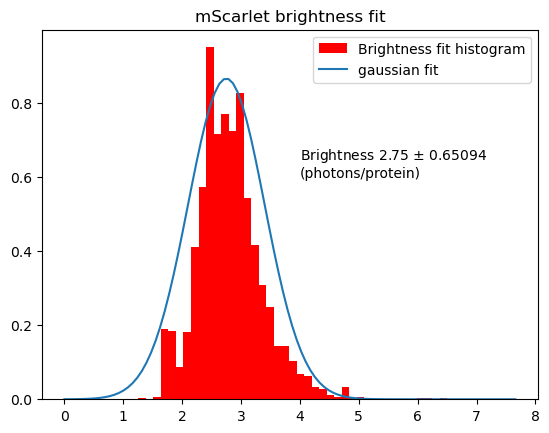

In [10]:
rhist, binedges = np.histogram(brvals, weights=1/(brerrs**2), bins=50, density=True)
rbincenters = np.diff(binedges)[0]/2 + binedges[:-1]

rpopt, rpcov = opt.curve_fit(gaussian, rbincenters, rhist)
rperr = np.sqrt(np.diag(rpcov))
print(rpopt)


plt.figure()
plt.title('mScarlet brightness fit')
# plt.plot(bincenters, rhist, )
plt.hist(brvals, weights=1/(brerrs**2), bins=50, density=True, color='r', label='Brightness fit histogram')
plt.plot(np.linspace(0, np.max(brvals), 100), gaussian(np.linspace(0, np.max(brvals), 100), rpopt[0], rpopt[1]), label='gaussian fit')
plt.text(4., 0.6, f'Brightness {round(rpopt[0],3)} $\pm$ {round(rpopt[1], 5)}\n(photons/protein)')
plt.legend()

plt.show()


# Test Brightness results

In [11]:
import re
import glob
import tifffile as tiif

In [12]:
print(filtxpos)
len(filtxpos)

[  6   7   8   9  10  11  12  13  29  30  31  37  38  39  40  41  42  46
  47  48  50  52  57  58  59  64  65  66  67  68  69  70  71  72  73  74
  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92
  93  94  95  96 100 101 102 103 104 105 106 107 108 109 110 111 112 113
 115 117 118 121 122 123 124 125 133 134 135 136 137 138 140 144 145 147
 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165
 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 189 190 191
 192 193 194 195 201 202 204 205 206 209 210 211 212 213 215 216 217 218
 219 220 221 233 234 235 236 237 238 239 251 252 256 257 258 259 260 261
 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276 277 278 279
 280 281 282 283 284 285 286 288 289 290 291 295 296 297 310 311 316 317
 318 319 320 321 322 323 333 334 336 337 338 339 342 343 344 345 346 347
 348 349 350 351 352 353 354 355 356 357 358 359 360 361 362 363 364 365
 366 367 368 369 370 371 374 375 376 377 378 379 38

640

IndexError: list index out of range

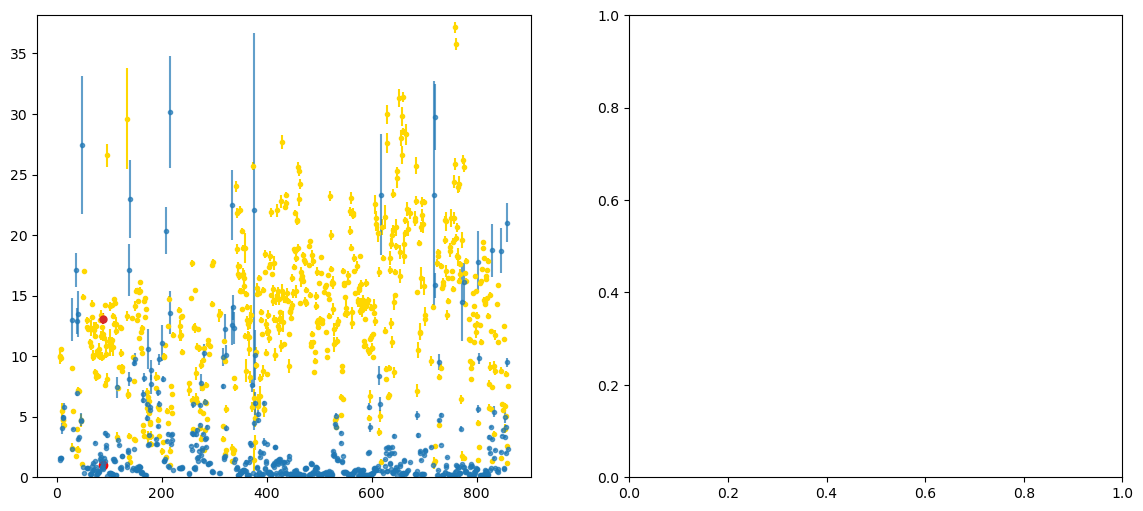

In [13]:
j = 59

for i in np.arange(50,88):
    j = filtxpos[i]
    path = r'C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs'

    ###
    f = files[j]
    name_ex = r'2025\d\d\d\d_.*_measurement\d*.*_set10'
    ma = re.search(name_ex, f)
    newf = glob.glob(path + r'/**/**/' + ma.group() + '.tiff')
    # print(newf[0])


    plt.subplots(1,2, figsize=(14,6))
    plt.subplot(1,2,1)
    plt.errorbar(filtxpos, filtyvals, yerr=filtyerrs, fmt='.', color='gold')
    plt.errorbar(j, filtyvals[filtxpos==j], yerr=filtyerrs[filtxpos==j], fmt='.', markersize=10, color='tab:red')
    plt.errorbar(filtxpos, filtnyvals, yerr=filtnyerr, fmt='.', alpha=0.7)
    plt.scatter(j, filtnyvals[filtxpos==j], c='r',)
    plt.ylim(0, np.max(filtyvals + 1))

    


    im = tif.imread(newf[0])[0, 0]
    plt.subplot(1,2,2)
    plt.title(newf[0][115:])
    plt.imshow(im)
    plt.colorbar()
    plt.show()
    ###


In [ ]:
monBs = np.linspace(-2., 5., 21) + y2popt[0]
dimBs = np.linspace(-2., 5., 21) + y2popt[1]
monerrs = np.zeros(len(monBs))
dimerrs = np.zeros(len(dimBs))

for i in range(len(monBs)):
    avgerrs = []
    for j in range(len(files)):
        f = files[j]
        fdict = np.load(f)
        cumulants = fdict['cumulants']
        variances = fdict['variances']
        Npixels = fdict['Npixels']

        if np.any(np.logical_not(np.isfinite(variances))) or np.any(np.logical_not(np.isfinite(cumulants))):
            print(f'file {j} bad value in:', f)
            continue

        cumulants = cumulants[Npixels > np.quantile(Npixels, 0.9)*0.75]
        variances = variances[Npixels > np.quantile(Npixels, 0.9)*0.75]
        max_len = 25 #cumulants.shape[1]//3 # just use the first half to avoid drift and bleaching.
        ymask = np.array([1, 0, 1, 0, 0, 1, 0, 0, 0])

        cum1cy = cumulants[:, ymask==1]
        var1cy = variances[:, ymask==1]
        try:
            fit1 = fc.fit_cumulants([1.0], [monBs[i]], [0], e2rad[0], cum1cy[:max_len], var1cy[:max_len], two_color=False, varyN=True, varyB=False, varyback=False, varygamma=False)   
            avgerrs.append( fit1.params['N1'].stderr )
        except Exception as e:
            print(e)
            print(f'file {j} bad fit:', f)
    monerrs[i] = np.mean(avgerrs)

for i in range(len(dimBs)):
    avgerrs = []
    for j in range(len(files)):
        f = files[j]
        fdict = np.load(f)
        cumulants = fdict['cumulants']
        variances = fdict['variances']
        Npixels = fdict['Npixels']

        if np.any(np.logical_not(np.isfinite(variances))) or np.any(np.logical_not(np.isfinite(cumulants))):
            print(f'file {j} bad value in:', f)
            continue

        cumulants = cumulants[Npixels > np.quantile(Npixels, 0.9)*0.75]
        variances = variances[Npixels > np.quantile(Npixels, 0.9)*0.75]
        max_len = 25 #cumulants.shape[1]//3 # just use the first half to avoid drift and bleaching.
        ymask = np.array([1, 0, 1, 0, 0, 1, 0, 0, 0])

        cum1cy = cumulants[:, ymask==1]
        var1cy = variances[:, ymask==1]
        try:
            fit1 = fc.fit_cumulants([1.0], [dimBs[i]], [0], e2rad[0], cum1cy[:max_len], var1cy[:max_len], two_color=False, varyN=True, varyB=False, varyback=False, varygamma=False)   
            avgerrs.append( fit1.params['N1'].stderr )
        except Exception as e:
            print(e)
            print(f'file {j} bad fit:', f)
    dimerrs[i] = np.mean(avgerrs)




file 0 bad value in: C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\cumulants_allstaygold\20250124_at1r-g13_measurement1a_set10_cumulants.npz
file 5 bad value in: C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\cumulants_allstaygold\20250124_at1r-g13_measurement2_set10_cumulants.npz
file 146 bad value in: C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\cumulants_allstaygold\20250205_at1r-g13_measurement12a_set10_cumulants.npz
file 0 bad value in: C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\cumulants_allstaygold\20250124_at1r-g13_measurement1a_set10_cumulants.npz
file 5 bad value in: C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\cumulants_allstaygold\20250124_at1r-g13_measurement2_set10_cumulants.npz
file 146 bad value in: C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_new_F

In [ ]:
print(dimBs[i])

17.103493019480336


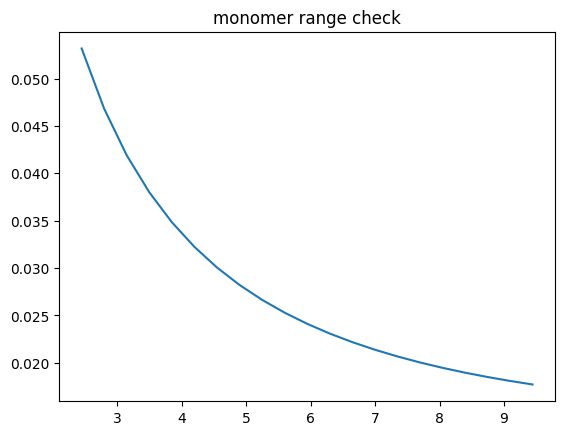

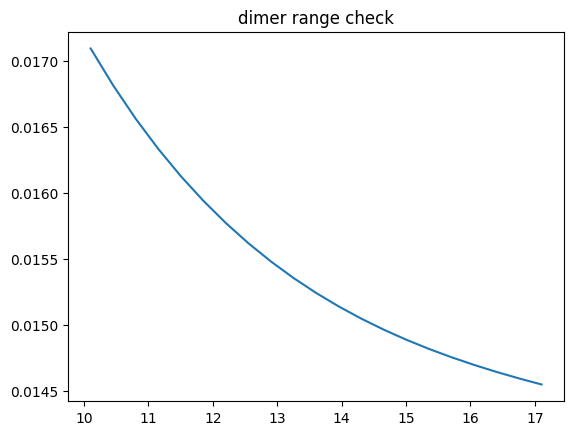

In [ ]:
plt.figure()
plt.title('monomer range check')
plt.plot(monBs, monerrs)
# plt.semilogy()

plt.figure()
plt.title('dimer range check')
plt.plot(dimBs, dimerrs)
# plt.semilogy()

plt.show()